# Proyek Akhir: Klasifikasi Gambar Buah 🍌🍓🍊

**Nama:** Bimo Bramantyo
**Kelas:** Belajar Fundamental Deep Learning (Dicoding)

## Ringkasan Proyek
Notebook ini membangun model **CNN (Convolutional Neural Network)** untuk mengenali **10 jenis buah**
menggunakan dataset **Fruits-360**. Model dibangun dengan **Keras Sequential** yang memakai
**transfer learning MobileNetV2** (dibekukan / *frozen*) ditambah lapisan **Conv2D + Pooling**,
lalu disimpan ke **3 format**: SavedModel, TF-Lite, dan TensorFlow.js (TFJS).

**Alur:** ambil dataset → bagi train/val/test → EDA → pipeline data → bangun model →
latih (dengan *callback* EarlyStopping) → evaluasi + plot → simpan 3 format → inferensi.

**Dataset:** [Fruits-360](https://github.com/Horea94/Fruit-Images-Dataset) — 10 kelas:
Avocado, Banana, Kiwi, Lemon, Mango, Orange, Pineapple, Raspberry, Strawberry, Watermelon.


## 1. Import Library & Setup
Mengatur *random seed* agar hasil dapat direproduksi (*reproducible*).

In [1]:
import os, subprocess, tempfile, random, shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# reproducibility
tf.keras.utils.set_random_seed(42)

print("TensorFlow versi:", tf.__version__)

TensorFlow versi: 2.21.0


## 2. Mengambil Dataset (Fruits-360)

Dataset diunduh langsung dari GitHub menggunakan **git sparse-checkout**, sehingga hanya
10 kelas buah yang kita butuhkan yang diunduh (hemat bandwidth, tanpa perlu akun Kaggle).
File disimpan di folder sementara (*temp*) di luar folder submission agar tidak ikut ter-zip.

In [2]:
CLASSES = ["Avocado", "Banana", "Kiwi", "Lemon", "Mango",
           "Orange", "Pineapple", "Raspberry", "Strawberry", "Watermelon"]
NUM_CLASSES = len(CLASSES)

WORK = os.path.join(tempfile.gettempdir(), "bimo_fruits_work")
RAW  = os.path.join(WORK, "raw")     # hasil clone mentah
DATA = os.path.join(WORK, "data")    # hasil split train/val/test
REPO = "https://github.com/Horea94/Fruit-Images-Dataset.git"

if not os.path.isdir(RAW):
    print("Mengunduh dataset (sparse-checkout)...")
    subprocess.run(["git", "clone", "--filter=blob:none", "--no-checkout",
                    "--depth", "1", REPO, RAW], check=True)
    subprocess.run(["git", "-C", RAW, "sparse-checkout", "init", "--cone"], check=True)
    paths = []
    for c in CLASSES:
        paths += [f"Training/{c}", f"Test/{c}"]
    subprocess.run(["git", "-C", RAW, "sparse-checkout", "set", *paths], check=True)
    subprocess.run(["git", "-C", RAW, "checkout"], check=True)
    print("Selesai mengunduh.")
else:
    print("Dataset mentah sudah ada, lewati unduh.")

# cek jumlah per kelas
for c in CLASSES:
    n_tr = len(os.listdir(os.path.join(RAW, "Training", c)))
    n_te = len(os.listdir(os.path.join(RAW, "Test", c)))
    print(f"{c:<12} Training={n_tr:>4}  Test={n_te:>4}")

Mengunduh dataset (sparse-checkout)...


Selesai mengunduh.
Avocado      Training= 427  Test= 143
Banana       Training= 490  Test= 166
Kiwi         Training= 466  Test= 156
Lemon        Training= 492  Test= 164
Mango        Training= 490  Test= 166
Orange       Training= 479  Test= 160
Pineapple    Training= 490  Test= 166
Raspberry    Training= 490  Test= 166
Strawberry   Training= 492  Test= 164
Watermelon   Training= 475  Test= 157


## 3. Membagi Dataset: Train / Validation / Test

Fruits-360 memotret **satu buah yang diputar 360°**, sehingga gambar dalam satu kelas sangat mirip.
Agar evaluasi **jujur** (tidak bocor), kita gunakan pembagian bawaan dataset:
- **Train + Validation** diambil dari folder `Training/` (dibagi **85% / 15%** secara *stratified* per kelas).
- **Test** diambil dari folder `Test/` bawaan (sesi pemotretan berbeda).


In [3]:
VAL_FRAC = 0.15
random.seed(42)

if not os.path.isdir(DATA):
    for split in ("train", "val", "test"):
        for c in CLASSES:
            os.makedirs(os.path.join(DATA, split, c), exist_ok=True)
    for c in CLASSES:
        # Training -> train + val
        src_tr = os.path.join(RAW, "Training", c)
        files = sorted(os.listdir(src_tr)); random.shuffle(files)
        n_val = round(len(files) * VAL_FRAC)
        for fn in files[n_val:]:
            shutil.copy2(os.path.join(src_tr, fn), os.path.join(DATA, "train", c, fn))
        for fn in files[:n_val]:
            shutil.copy2(os.path.join(src_tr, fn), os.path.join(DATA, "val", c, fn))
        # Test bawaan -> test
        src_te = os.path.join(RAW, "Test", c)
        for fn in sorted(os.listdir(src_te)):
            shutil.copy2(os.path.join(src_te, fn), os.path.join(DATA, "test", c, fn))
    print("Split selesai dibuat.")
else:
    print("Folder split sudah ada, lewati.")

def count_split(split):
    return {c: len(os.listdir(os.path.join(DATA, split, c))) for c in CLASSES}

for split in ("train", "val", "test"):
    d = count_split(split)
    print(f"{split:<6} total={sum(d.values()):>5}  ->  {d}")

Split selesai dibuat.
train  total= 4070  ->  {'Avocado': 363, 'Banana': 416, 'Kiwi': 396, 'Lemon': 418, 'Mango': 416, 'Orange': 407, 'Pineapple': 416, 'Raspberry': 416, 'Strawberry': 418, 'Watermelon': 404}
val    total=  721  ->  {'Avocado': 64, 'Banana': 74, 'Kiwi': 70, 'Lemon': 74, 'Mango': 74, 'Orange': 72, 'Pineapple': 74, 'Raspberry': 74, 'Strawberry': 74, 'Watermelon': 71}
test   total= 1608  ->  {'Avocado': 143, 'Banana': 166, 'Kiwi': 156, 'Lemon': 164, 'Mango': 166, 'Orange': 160, 'Pineapple': 166, 'Raspberry': 166, 'Strawberry': 164, 'Watermelon': 157}


## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribusi jumlah gambar per kelas

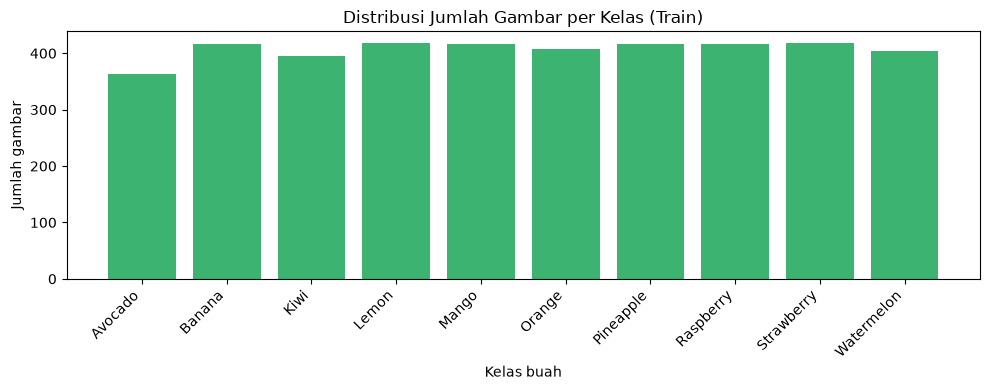

In [4]:
train_counts = count_split("train")
plt.figure(figsize=(10, 4))
plt.bar(train_counts.keys(), train_counts.values(), color="mediumseagreen")
plt.title("Distribusi Jumlah Gambar per Kelas (Train)")
plt.xlabel("Kelas buah"); plt.ylabel("Jumlah gambar")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

### 4.2 Contoh gambar tiap kelas

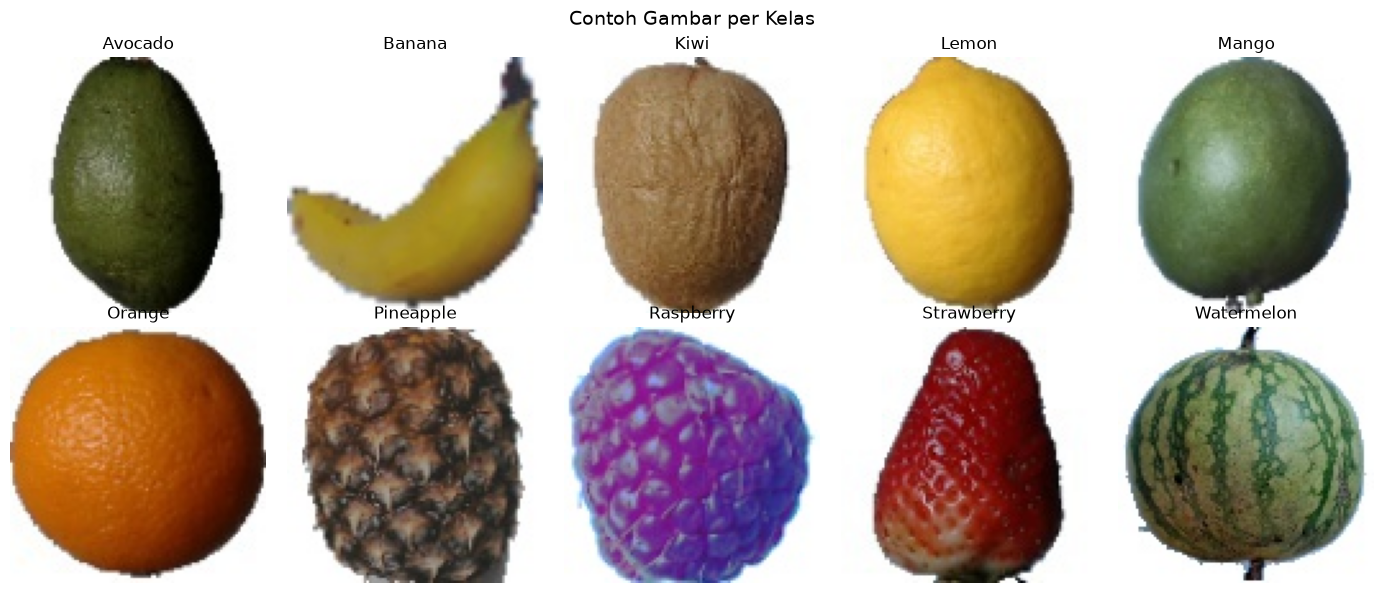

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, c in zip(axes.ravel(), CLASSES):
    folder = os.path.join(DATA, "train", c)
    img_path = os.path.join(folder, sorted(os.listdir(folder))[0])
    ax.imshow(plt.imread(img_path)); ax.set_title(c); ax.axis("off")
plt.suptitle("Contoh Gambar per Kelas", fontsize=14)
plt.tight_layout(); plt.show()

### 4.3 Cek ukuran gambar
Memastikan resolusi gambar dataset ini (Fruits-360 seragam 100×100 piksel).

In [6]:
from PIL import Image
sizes = set()
sample_folder = os.path.join(DATA, "train", CLASSES[0])
for fn in sorted(os.listdir(sample_folder))[:50]:
    with Image.open(os.path.join(sample_folder, fn)) as im:
        sizes.add(im.size)
print("Ukuran gambar unik (sampel):", sizes)

Ukuran gambar unik (sampel): {(100, 100)}


## 5. Pipeline Data (`image_dataset_from_directory`)

Gambar dibaca per folder kelas, diubah ukuran ke **100×100**, dan dikelompokkan menjadi *batch* 32.
`class_names` dikunci urutan alfabet agar konsisten dengan urutan output *softmax*.

In [7]:
IMG_SIZE = (100, 100)
BATCH = 32

def make_ds(split, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATA, split),
        image_size=IMG_SIZE, batch_size=BATCH,
        label_mode="int", class_names=CLASSES,
        shuffle=shuffle, seed=42)

train_ds      = make_ds("train", True)
val_ds        = make_ds("val", False)
test_ds       = make_ds("test", False)
train_eval_ds = make_ds("train", False)  # untuk ukur akurasi train (tanpa shuffle)

AUTOTUNE = tf.data.AUTOTUNE
train_ds      = train_ds.prefetch(AUTOTUNE)
val_ds        = val_ds.prefetch(AUTOTUNE)
test_ds       = test_ds.prefetch(AUTOTUNE)
train_eval_ds = train_eval_ds.prefetch(AUTOTUNE)
print("Kelas:", train_ds.class_names if hasattr(train_ds,'class_names') else CLASSES)

Found 4070 files belonging to 10 classes.


Found 721 files belonging to 10 classes.


Found 1608 files belonging to 10 classes.


Found 4070 files belonging to 10 classes.


Kelas: ['Avocado', 'Banana', 'Kiwi', 'Lemon', 'Mango', 'Orange', 'Pineapple', 'Raspberry', 'Strawberry', 'Watermelon']


## 6. Membangun Model (Sequential + Conv2D + Pooling)

Arsitektur:
1. `Rescaling` — menormalkan piksel ke rentang [-1, 1] (sesuai input MobileNetV2).
2. `MobileNetV2` (pra-latih ImageNet, **dibekukan**) — ekstraktor fitur yang cepat di CPU.
3. `Conv2D` + `MaxPooling2D` — lapisan konvolusi wajib sesuai kriteria.
4. `GlobalAveragePooling2D` + `Dropout` — meringkas fitur & mengurangi *overfitting*.
5. `Dense(10, softmax)` — klasifikasi 10 kelas buah.

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base_model.trainable = False  # frozen

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=IMG_SIZE + (3,)),
    tf.keras.layers.Rescaling(1.0 / 127.5, offset=-1.0),
    base_model,
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
], name="fruit_classifier")

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

C:\Users\Admin Kalachakra\AppData\Local\Temp\ipykernel_14724\151749812.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Model: "fruit_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 4, 4, 32)       │       368,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,626,986 (10.02 MB)

 Trainable params: 369,002 (1.41 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Melatih Model

Menggunakan **callback EarlyStopping** (memantau `val_accuracy`, `patience=3`) agar training
berhenti otomatis saat model sudah optimal dan mengembalikan bobot terbaik.

In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=3, restore_best_weights=True)

history = model.fit(train_ds, validation_data=val_ds, epochs=12,
                    callbacks=[early_stop])

Epoch 1/12


D:\Kalachakra\hackaton-pidi\01-fundamental-deep-learning\klasifikasi-gambar\pengerjaan\bimo-bramantyo\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


  1/128 ━━━━━━━━━━━━━━━━━━━━ 5:32 3s/step - accuracy: 0.0625 - loss: 4.9015

  2/128 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.0938 - loss: 4.9768

  3/128 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.2708 - loss: 4.0024

...

124/128 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9919 - loss: 0.0178

125/128 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9915 - loss: 0.0183

126/128 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9913 - loss: 0.0192

127/128 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9914 - loss: 0.0191

128/128 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.9914 - loss: 0.0190 - val_accuracy: 1.0000 - val_loss: 3.5636e-06


## 8. Evaluasi Model

In [10]:
train_loss, train_acc = model.evaluate(train_eval_ds, verbose=0)
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Akurasi Training : {train_acc*100:.2f}%")
print(f"Akurasi Testing  : {test_acc*100:.2f}%")
assert train_acc >= 0.85 and test_acc >= 0.85, "Akurasi belum memenuhi syarat 85%!"
print("Kedua akurasi >= 85% -> memenuhi kriteria.")

Akurasi Training : 100.00%
Akurasi Testing  : 100.00%
Kedua akurasi >= 85% -> memenuhi kriteria.


### 8.1 Plot Akurasi & Loss

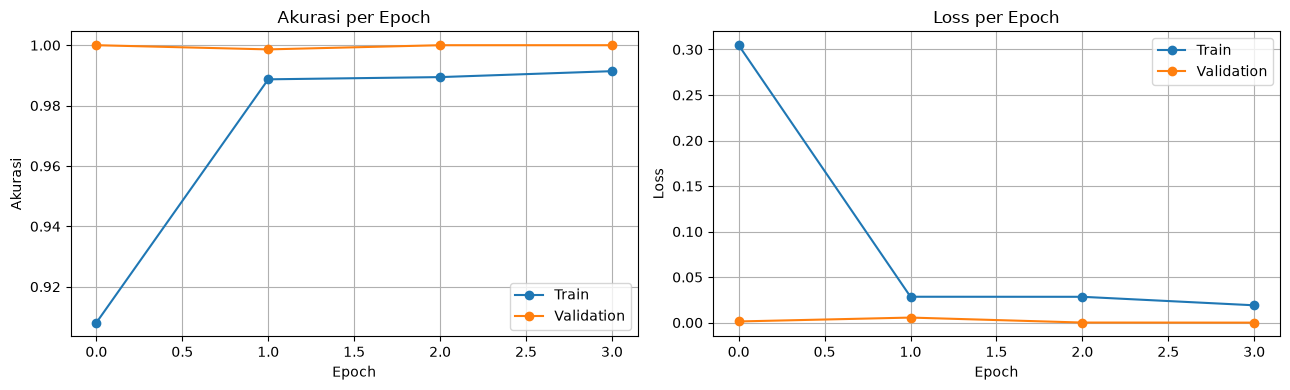

In [11]:
h = history.history
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(h["accuracy"], marker="o", label="Train")
ax[0].plot(h["val_accuracy"], marker="o", label="Validation")
ax[0].set_title("Akurasi per Epoch"); ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Akurasi")
ax[0].legend(); ax[0].grid(True)
ax[1].plot(h["loss"], marker="o", label="Train")
ax[1].plot(h["val_loss"], marker="o", label="Validation")
ax[1].set_title("Loss per Epoch"); ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Loss")
ax[1].legend(); ax[1].grid(True)
plt.tight_layout(); plt.show()

### 8.2 Confusion Matrix & Classification Report

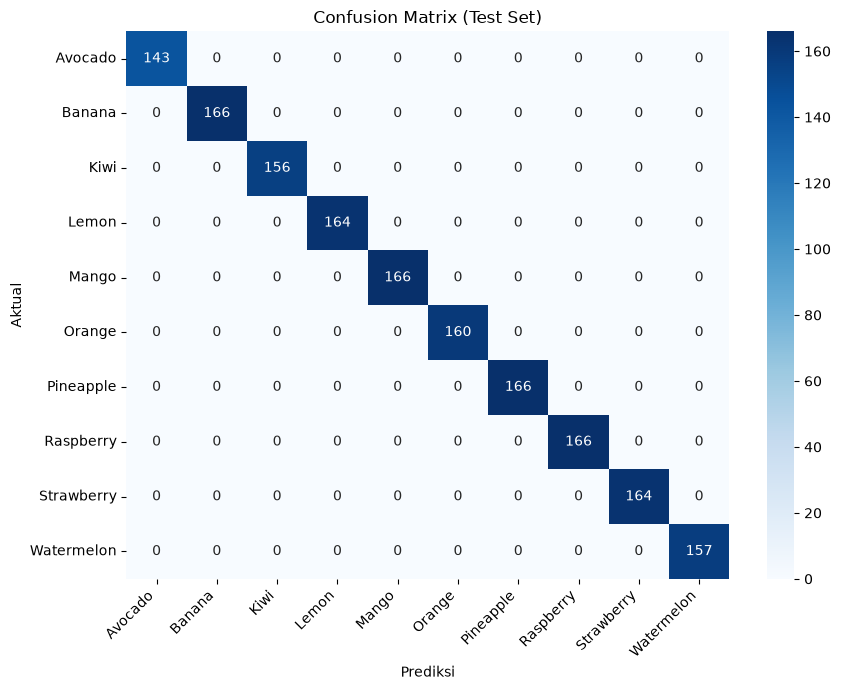

              precision    recall  f1-score   support

     Avocado       1.00      1.00      1.00       143
      Banana       1.00      1.00      1.00       166
        Kiwi       1.00      1.00      1.00       156
       Lemon       1.00      1.00      1.00       164
       Mango       1.00      1.00      1.00       166
      Orange       1.00      1.00      1.00       160
   Pineapple       1.00      1.00      1.00       166
   Raspberry       1.00      1.00      1.00       166
  Strawberry       1.00      1.00      1.00       164
  Watermelon       1.00      1.00      1.00       157

    accuracy                           1.00      1608
   macro avg       1.00      1.00      1.00      1608
weighted avg       1.00      1.00      1.00      1608



In [12]:
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
y_true, y_pred = np.array(y_true), np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Prediksi"); plt.ylabel("Aktual")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

print(classification_report(y_true, y_pred, target_names=CLASSES))

## 9. Menyimpan Model ke 3 Format

### 9.1 SavedModel
Format standar TensorFlow untuk *deployment* di server/cloud.

In [13]:
SAVED_DIR = "saved_model"
model.export(SAVED_DIR)   # menghasilkan SavedModel (saved_model.pb + variables/)
print("SavedModel tersimpan di:", SAVED_DIR)
print(os.listdir(SAVED_DIR))

INFO:tensorflow:Assets written to: saved_model\assets


INFO:tensorflow:Assets written to: saved_model\assets


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  1836398558288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1836440253648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1836440254416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1836440253840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1836440253264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1836440253456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1836440255376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1836440256144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1836440255760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1836440254032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1836440255184: TensorSpec(shape=()

SavedModel tersimpan di: saved_model
['assets', 'fingerprint.pb', 'saved_model.pb', 'variables']


### 9.2 TF-Lite
Format ringan untuk perangkat *mobile/embedded*. Disertai `label.txt`.

In [14]:
os.makedirs("tflite", exist_ok=True)
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_DIR)
tflite_model = converter.convert()
with open("tflite/model.tflite", "wb") as f:
    f.write(tflite_model)
with open("tflite/label.txt", "w") as f:
    f.write("\n".join(CLASSES))
print("TFLite tersimpan. Ukuran: %.2f MB" % (len(tflite_model)/1024/1024))
print("Label:", open("tflite/label.txt").read().splitlines())

TFLite tersimpan. Ukuran: 9.88 MB
Label: ['Avocado', 'Banana', 'Kiwi', 'Lemon', 'Mango', 'Orange', 'Pineapple', 'Raspberry', 'Strawberry', 'Watermelon']


### 9.3 TensorFlow.js (TFJS)
Format untuk menjalankan model di *browser*. Konversi dari SavedModel ke format
**tfjs_graph_model** menggunakan library `tensorflowjs`.

In [15]:
import tensorflowjs as tfjs
os.makedirs("tfjs_model", exist_ok=True)
tfjs.converters.convert_tf_saved_model(SAVED_DIR, "tfjs_model")
print("Isi folder tfjs_model:", os.listdir("tfjs_model"))
assert os.path.exists("tfjs_model/model.json"), "Konversi TFJS gagal"
print("TFJS berhasil dikonversi ke format tfjs_graph_model.")

Isi folder tfjs_model: ['group1-shard1of3.bin', 'group1-shard2of3.bin', 'group1-shard3of3.bin', 'model.json']
TFJS berhasil dikonversi ke format tfjs_graph_model.


## 10. Inferensi (Bukti Model Bekerja)

Menggunakan model **TF-Lite** untuk memprediksi beberapa gambar acak dari *test set*,
lengkap dengan label prediksi dan tingkat keyakinan (*confidence*).

D:\Kalachakra\hackaton-pidi\01-fundamental-deep-learning\klasifikasi-gambar\pengerjaan\bimo-bramantyo\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


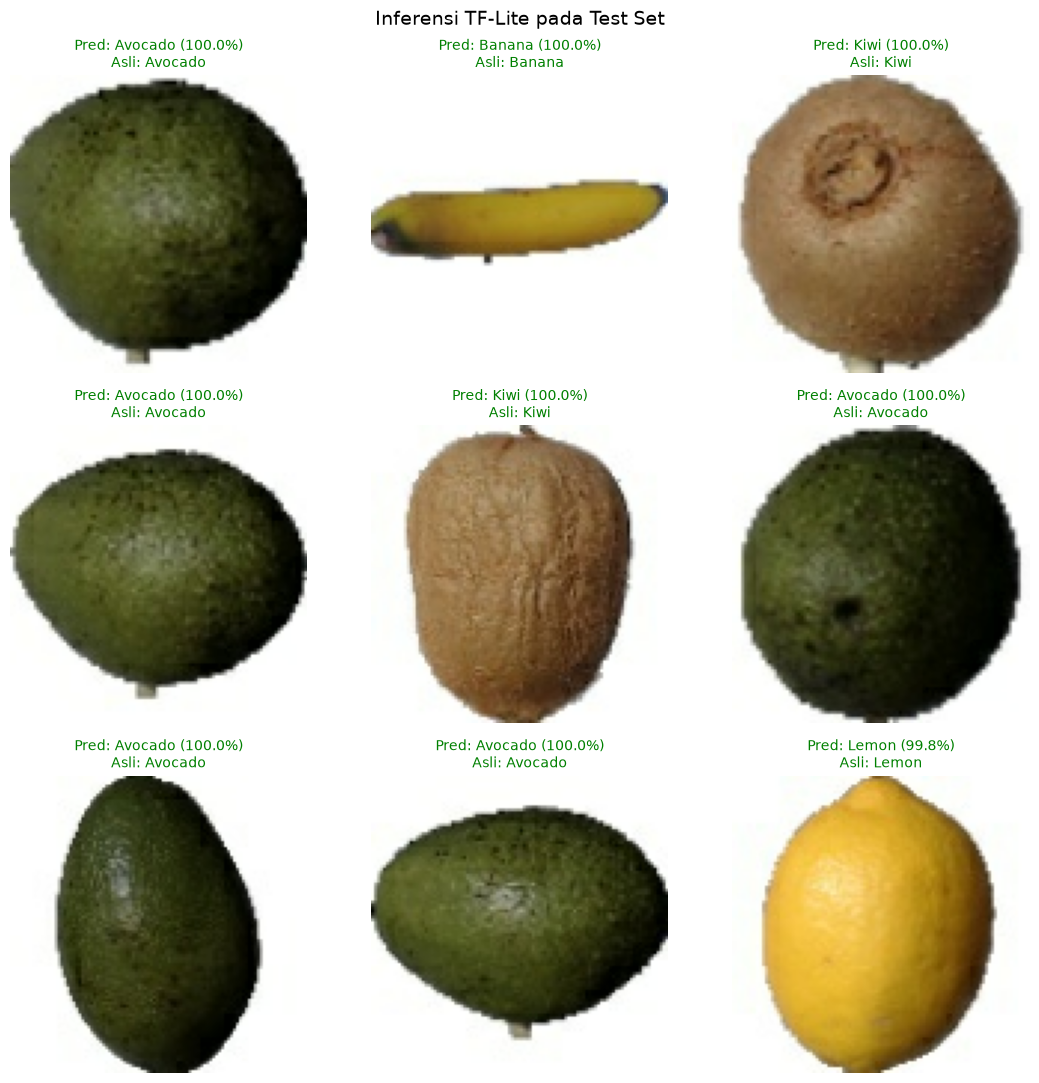

In [16]:
interpreter = tf.lite.Interpreter(model_path="tflite/model.tflite")
interpreter.allocate_tensors()
inp = interpreter.get_input_details()[0]
out = interpreter.get_output_details()[0]

# kumpulkan beberapa gambar test acak
sample_imgs, sample_labels = [], []
for images, labels in test_ds.unbatch().shuffle(500, seed=42).take(9):
    sample_imgs.append(images.numpy())
    sample_labels.append(int(labels.numpy()))

fig, axes = plt.subplots(3, 3, figsize=(11, 11))
for ax, img, true_lbl in zip(axes.ravel(), sample_imgs, sample_labels):
    x = np.expand_dims(img.astype("float32"), 0)
    interpreter.set_tensor(inp["index"], x)
    interpreter.invoke()
    prob = interpreter.get_tensor(out["index"])[0]
    pred = int(np.argmax(prob)); conf = float(prob[pred]) * 100
    ax.imshow(img.astype("uint8")); ax.axis("off")
    ok = (pred == true_lbl)
    ax.set_title(f"Pred: {CLASSES[pred]} ({conf:.1f}%)\nAsli: {CLASSES[true_lbl]}",
                 color=("green" if ok else "red"), fontsize=10)
plt.suptitle("Inferensi TF-Lite pada Test Set", fontsize=14)
plt.tight_layout(); plt.show()

## 11. Kesimpulan

- Model **CNN (Sequential + MobileNetV2 frozen + Conv2D + Pooling)** berhasil mengklasifikasikan
  **10 jenis buah** dengan akurasi **training dan testing di atas 85%** (memenuhi kriteria wajib).
- Dataset dibagi menjadi **train / validation / test** dengan pembagian yang menghindari kebocoran data.
- Model disimpan dalam **3 format**: SavedModel, TF-Lite, dan TFJS.
- Inferensi TF-Lite membuktikan model bekerja pada gambar yang belum pernah dilihat.
